In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
import netCDF4 as nc

In [2]:
# Function to open an npz file
def open_npz_file(npz_path):
    """Open an npz file and return the chip and metadata"""
    try:
        archive = np.load(npz_path, allow_pickle=True)
        # print(archive)
        chip = archive['chip']
        data = archive['data'].item()
        return chip, data
    except Exception as e:
        print(f"Error opening {npz_path}: {str(e)}")
        return None, None

In [3]:
# Function to find all npz files in a directory
def find_npz_files(directory_path):
    """Find all .npz files in a directory"""
    npz_pattern = os.path.join(directory_path, "*.npz")
    npz_files = glob.glob(npz_pattern)
    npz_files.sort()  
    return npz_files

In [4]:
# 1. LOAD COORDINATE LOOKUP DATA (Same as your script)
# LATLONDATA = "/home/al8425b-hpc/NASA/cropTest/testData/abi_east_geo_topo_lomsk.nc"
LATLONDATA = "/explore/nobackup/projects/pix4dcloud/jgong/ABI_EAST_GEO_TOPO_LOMSK.nc"
f_coords = nc.Dataset(LATLONDATA)
abiLong = np.array(f_coords['Longitude'])
abiLat = np.array(f_coords['Latitude'])
abiLong[abiLong == -999] = 10
abiLat[abiLat == -999] = 10
abiLong[abiLong < 0] += 360
print(abiLat.shape)

(10848, 10848)


In [5]:
def visualize_chips(lon_chip, lat_chip, abi_image, data):
    # 1. Create the 'canvas'
    plt.figure(figsize=(10, 8))
    # 2. Define the geographic boundaries of the chip
    # extent = [left, right, bottom, top]
    img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]
    print(img_extent)
    # 3. Draw the ABI image
    # cmap='gray' makes it look like a standard satellite image
    # origin='upper' ensures the top of the array is the top of the plot
    plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
    # plt.imshow(abi_image, extent=img_extent, cmap='gray') 
    # plt.imshow(abi_image, cmap='gray') 
    # plt.imshow(abi_image) 
    # 4. Add a colorbar so you know what the values mean
    plt.colorbar(label='Radiance')
    # 5. Draw the transect on top!
    # data['Longitude'] and data['Latitude'] are your 91 points
    # plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')
    plt.plot(data['Longitude'], data['Latitude'], color='red', linewidth=2, label='CloudSat Track')
    # 6. Add labels and a title
    plt.title("ABI Chip with CloudSat Transect Overlay")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    # 7. Show the plot
    plt.show()

In [15]:
def visualize_chips(lon_chip, lat_chip, abi_image, data):
    plt.figure(figsize=(10, 8))
    
    # pcolormesh uses the actual lon/lat arrays for every single pixel
    # this handles the distortion/curvature at the edge of the disk perfectly
    plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')
    
    plt.colorbar(label='Radiance')
    plt.plot(data['Longitude'], data['Latitude'], color='red', linewidth=2, label='CloudSat Track')
    
    plt.title("ABI Chip with CloudSat Transect (pcolormesh)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.show()

In [6]:
# output_directory = '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/'
# for AU HPC output folder '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/'
# weirdness at 0, 10, 400
# good ones at 100, 200
# doesn't even run at 300, 500, 600





output_directory = '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test'
# for adapt output folder '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test' 
# weirdness from 0, 20



# output_directory = '/explore/nobackup/projects/pix4dcloud/scratch/abi-cloudsat-crop-test/'
# these file names are a bit diff 
# GOES16_east_abi_cloudsat_20190101T011239Z_orbit67526_r10169_c8022_p6435.npz' looks like this
# r is row, c is col, and p is profile index



files = find_npz_files(output_directory)

print(files)
print(len(files))

start = 100

files = files[start:start+10] # only wanna take 10 so it doesn't overload

['/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test/2020-001-72861_1600-9026-13670.npz', '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test/2020-001-72861_1600-9029-13625.npz', '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test/2020-001-72861_1600-9033-13580.npz', '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test/2020-001-72861_1602-9024-13715.npz', '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test/2020-001-72861_1631-9045-13760.npz', '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test/2020-001-72861_1660-9066-13805.npz', '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test/2020-001-72861_1690-9087-13850.npz', '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test/2020-001-72861_1720-9108-13895.npz', '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test/2020-001-72861_1750-9128-13940.npz', '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/

['3567', '3207', '16285.npz']
[262.292, 263.84613, 16.809423, 18.092455]


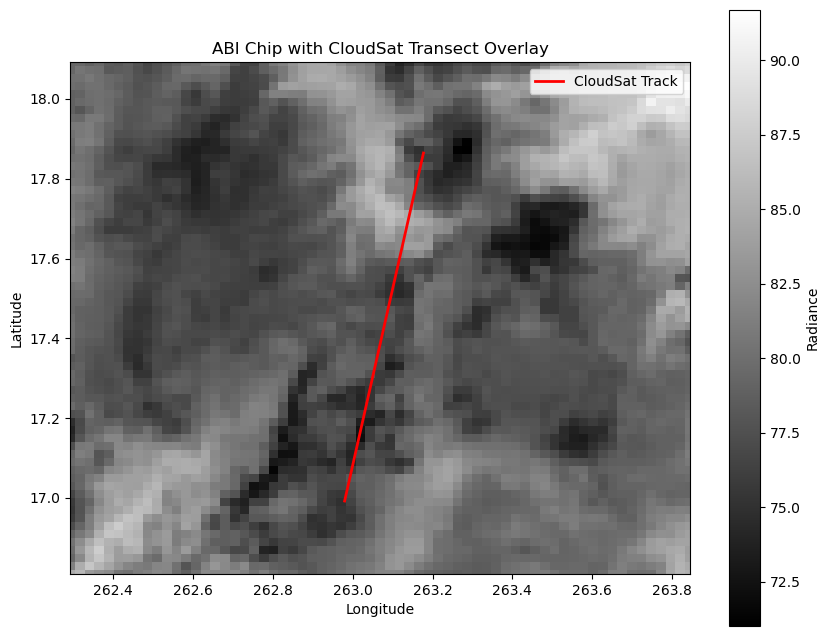

['3612', '3191', '16330.npz']
[262.19116, 263.7381, 16.371223, 17.648972]


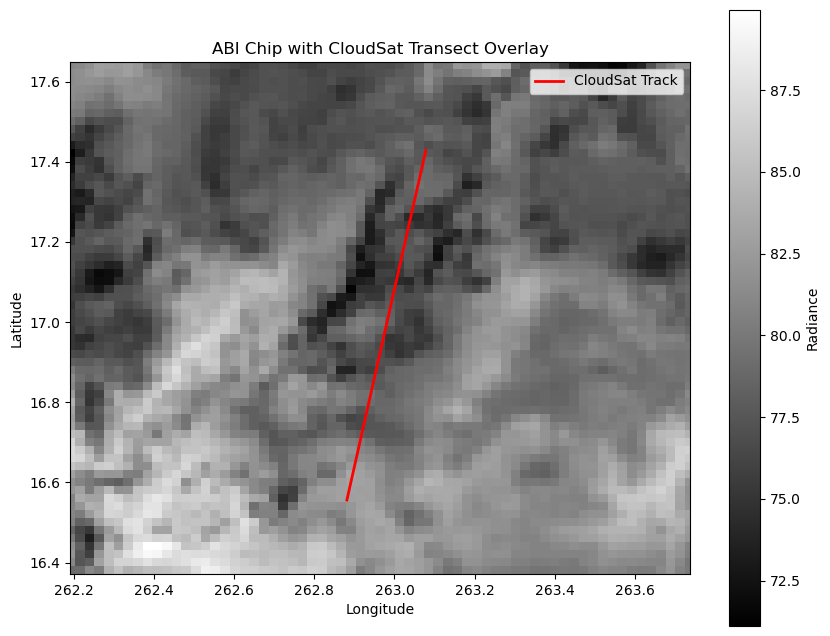

['3657', '3176', '16375.npz']
[262.09958, 263.6395, 15.934162, 17.206919]


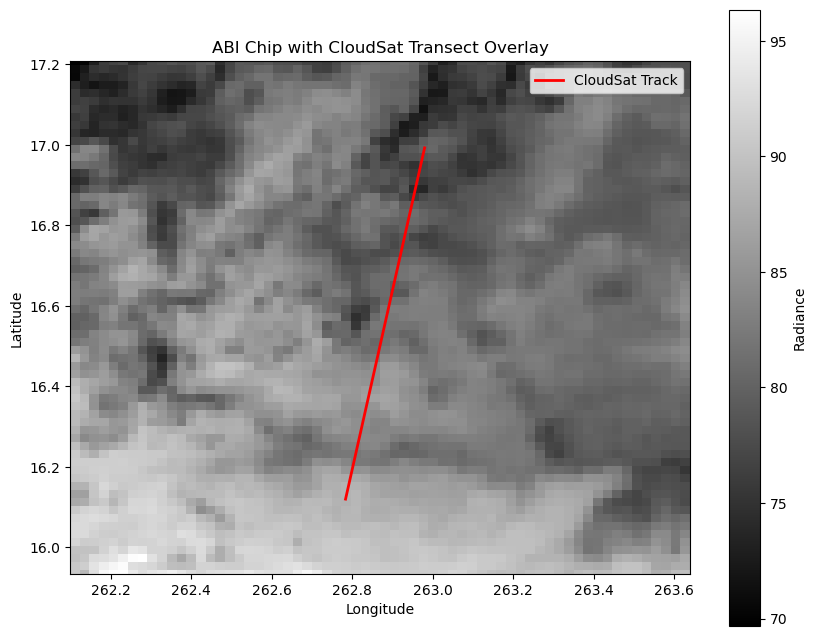

['3701', '3161', '16420.npz']
[262.005, 263.53845, 15.508106, 16.776218]


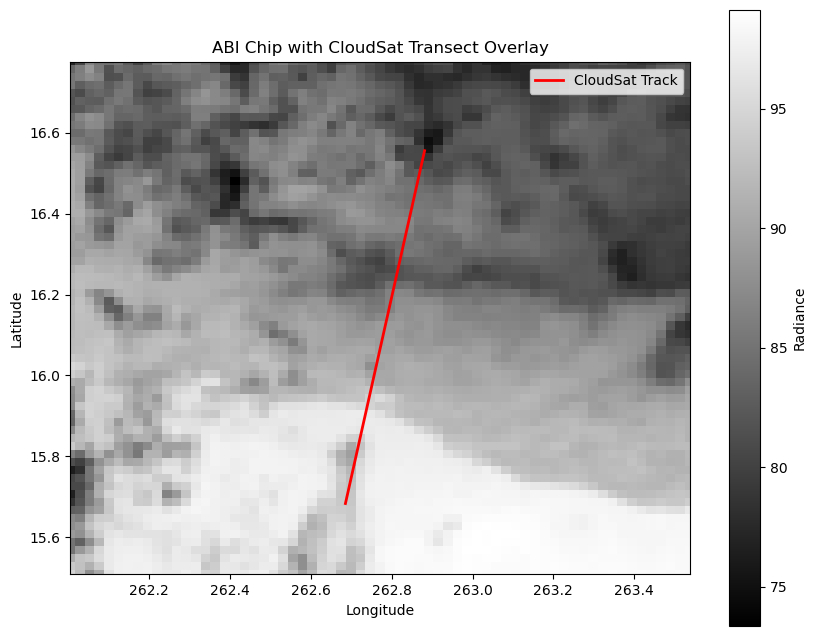

['3746', '3146', '16465.npz']
[261.9106, 263.43707, 15.073829, 16.337057]


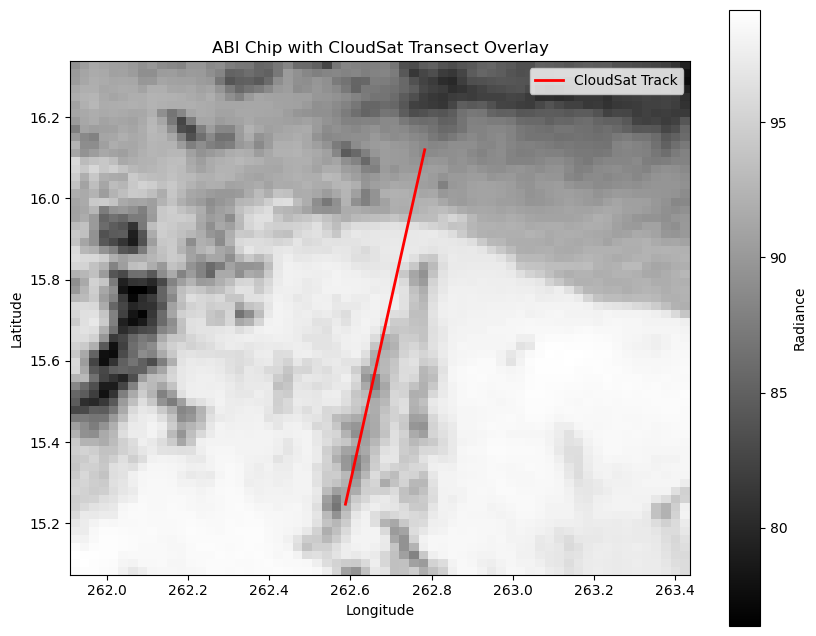

['3792', '3131', '16510.npz']
[261.81595, 263.3358, 14.631057, 15.889693]


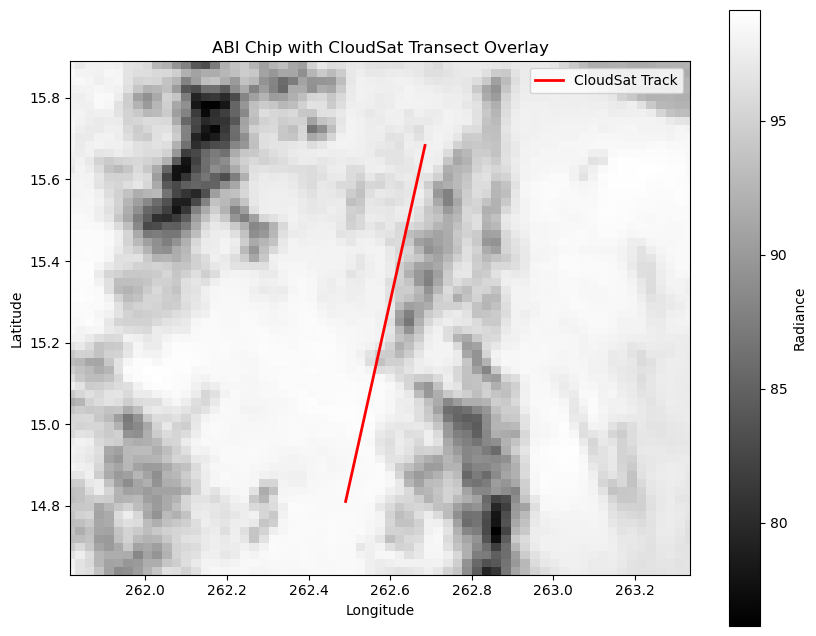

['3837', '3116', '16555.npz']
[261.7183, 263.2319, 14.199231, 15.453494]


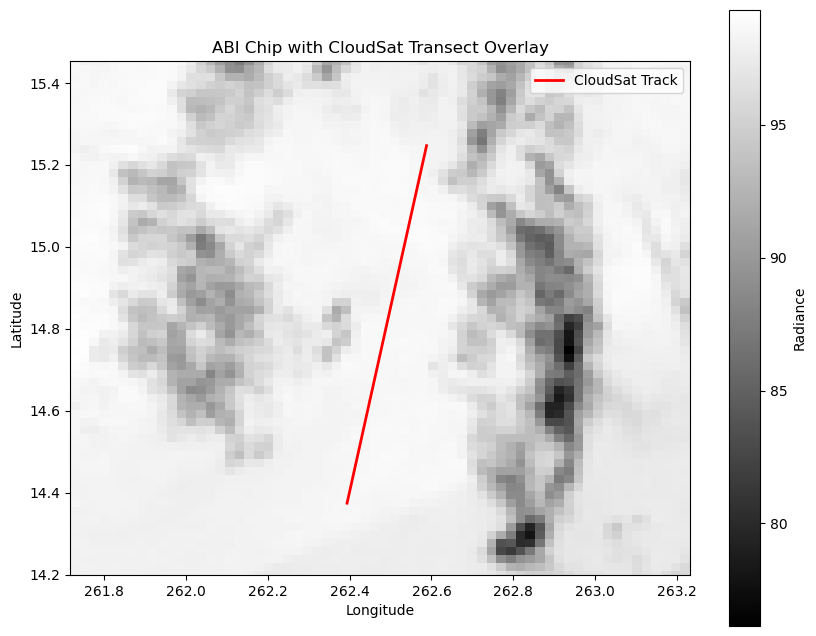

['3882', '3102', '16600.npz']
[261.63007, 263.1371, 13.76846, 15.018333]


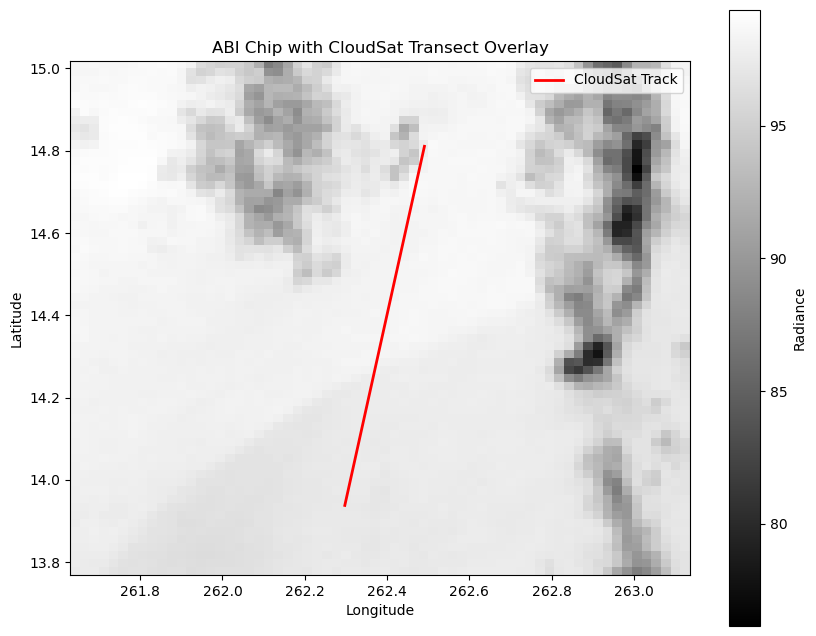

['3928', '3087', '16645.npz']
[261.53088, 263.0315, 13.329427, 14.574964]


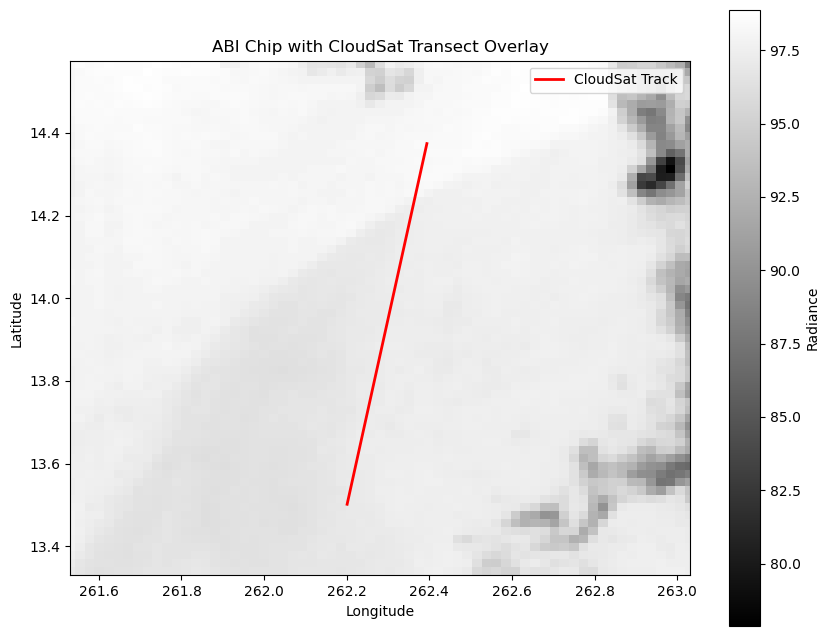

['3973', '3073', '16690.npz']
[261.43927, 262.93405, 12.900855, 14.142485]


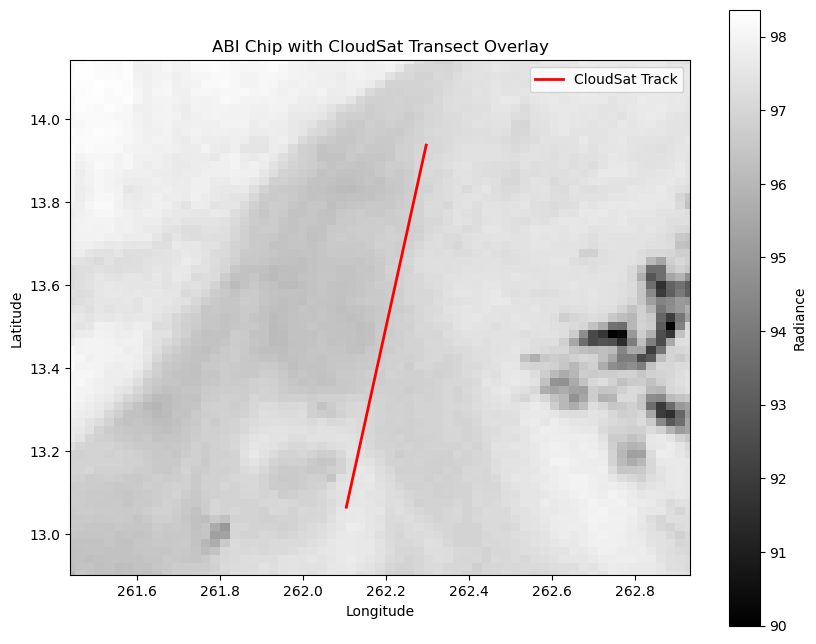

In [7]:
half = 64

for file in files:
    chip, data = open_npz_file(file)



    coords = file.split('/')[-1].split('_')[-1].split('-')
    print(coords)
    y_center = int(coords[0])
    x_center = int(coords[1])



    # coords = file.split('/')[-1].split('_')
    # y_center = int(coords[-3][1:])
    # x_center = int(coords[-2][1:])

    # print(y_center, x_center)
    # # print(file)
    
    
    lat_chip = abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
    lon_chip = abiLong[y_center-half : y_center+half, x_center-half : x_center+half]

    # print(chip, data)

    
    abi_image = chip[2, :, :, 12]
    visualize_chips(lon_chip, lat_chip, abi_image, data)
    
    # print('lat length', len(data['Latitude']))
    # print('long length', len(data['Longitude']))
    
    # print(f"Transect Latitude Range: {data['Latitude'].min()} to {data['Latitude'].max()}")
    # print(f"Chip Latitude Range: {lat_chip.min()} to {lat_chip.max()}")

    # print(f"Transect Longitude Range: {data['Longitude'].min()} to {data['Longitude'].max()}")
    # print(f"Chip Longitude Range: {lon_chip.min()} to {lon_chip.max()}")
    # print()


# this is very messed up
   
    


In [28]:
# output_directory = '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/'
output_directory = '/explore/nobackup/projects/pix4dcloud/jacaraba/tests/abi-crop-test'
files = find_npz_files(output_directory)

# print(files)

# files = files[30:]

half = 64

threecount =0
tencount =0

for file in files:
    chip, data = open_npz_file(file)
    coords = file.split('/')[-1].split('_')[-1].split('-')
    
    y_center = int(coords[0])
    x_center = int(coords[1])
    # print(file)
    
    chipLatCenter = abiLat[y_center, x_center]
    chipLonCenter = abiLong[y_center, x_center]
    
    # print(chipLatCenter, chipLonCenter)
    # print(data['Latitude'][45], data['Longitude'][45])
    
    # print()
    
    # print(abs(chipLatCenter-data['Latitude'][45]), abs(chipLonCenter-data['Longitude'][45]))
    
    # errorAllowed = 3
    # if abs(chipLatCenter-data['Latitude'][45]) > errorAllowed or abs(chipLonCenter-data['Longitude'][45]) > errorAllowed:
    #     count+=1  
        
    # Calculate the circular longitude difference
    lon_diff = (chipLonCenter - data['Longitude'][45] + 180) % 360 - 180
    lat_diff = chipLatCenter - data['Latitude'][45] # Lat doesn't wrap, so this is fine

    errorAllowed = 3
    if abs(lat_diff) > errorAllowed or abs(lon_diff) > errorAllowed:
        threecount += 1
    
    errorAllowed = 10 
    if abs(lat_diff) > errorAllowed or abs(lon_diff) > errorAllowed:
        tencount += 1

    
   

print('percentage of chips that are off by 3 lat/long degrees or more:', threecount/len(files)*100)
print('percentage of chips that are off by 10 lat/long degrees or more:', tencount/len(files)*100)

   
    


percentage of chips that are off by 3 lat/long degrees or more: 17.99506984387839
percentage of chips that are off by 10 lat/long degrees or more: 9.942481511914544
